# Sistema de Recomendación - Modelado

**Proyecto:** Datalab - Sistema de Recomendación de Productos  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Autor:** Luis Crespo  
**Rol:** Data Engineer  

## Objetivo
Comparar tres enfoques de recomendación y justificar la elección del modelo final basándose en las características del dataset y los objetivos de negocio.

## Decisiones basadas en el EDA
1. **Collaborative Filtering descartado**: 97% de clientes únicos, sin historial suficiente
2. **Market Basket Analysis descartado**: 96.7% de órdenes con un solo producto
3. **Enfoque elegido**: Content-Based con comparación de métricas de similitud

## Modelos a comparar
- **Baseline**: Popularidad por categoría
- **Modelo 1**: Content-Based con similitud coseno
- **Modelo 2**: Content-Based con distancia euclidiana

In [2]:
"""
Sistema de Recomendación - Notebook de Modelado
================================================
Proyecto: Datalab
Autor: Luis Crespo
Rol: Data Engineer

Este notebook implementa la comparación de 3 modelos de recomendación
sobre el dataset limpio generado en el ETL. El modelo final se selecciona
basándose en métricas cuantitativas y objetivos de negocio.
"""

# Librerías estándar de análisis de datos
import pandas as pd
import numpy as np

# Preprocesamiento y modelos
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# Visualización
import matplotlib.pyplot as plt

# Configuración
import warnings
warnings.filterwarnings('ignore')

# Cargar el dataset limpio generado en el ETL
df = pd.read_csv("olist_limpio.csv")

print("=" * 60)
print("CARGA DEL DATASET LIMPIO")
print("=" * 60)
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nColumnas disponibles:")
for col in df.columns.tolist():
    print(f"  - {col}")

CARGA DEL DATASET LIMPIO
Dimensiones: 98,771 filas x 15 columnas

Columnas disponibles:
  - customer_unique_id
  - order_id
  - product_id
  - product_category_name
  - price
  - product_weight_g
  - product_length_cm
  - product_height_cm
  - product_width_cm
  - customer_city
  - customer_state
  - order_purchase_timestamp
  - volumen_producto
  - anio_compra
  - mes_compra


## 1. Ingeniería de Características para el Modelo

Aunque las features principales (`volumen_producto`, `anio_compra`, `mes_compra`)
ya fueron creadas en el ETL, aquí se agregan transformaciones específicas
para preparar los datos para los modelos de recomendación:

- **category_encoded**: Categoría convertida a variable numérica (LabelEncoder)
- **Agregación por producto**: Se agrupa el dataset por `product_id` calculando
  el promedio de las features numéricas
- **Normalización**: Se escalan las features a rango [0,1] con MinMaxScaler para
  que la distancia euclidiana no sea dominada por variables de mayor magnitud

In [3]:
"""
PREPARACIÓN DE DATOS PARA MODELADO
Transformamos el dataset a nivel de producto único y normalizamos features.
"""

# Codificar categoría del producto como variable numérica
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['product_category_name'].astype(str))

# Agregar dataset a nivel de producto único
# Un producto puede aparecer en múltiples órdenes, tomamos el promedio
product_features = df.groupby('product_id').agg({
    'price': 'mean',
    'product_weight_g': 'mean',
    'volumen_producto': 'mean',
    'category_encoded': 'first',
    'product_category_name': 'first'
}).reset_index()

print(f"Total productos únicos en el dataset: {len(product_features):,}")

# Muestra representativa para evitar problemas de memoria en Colab gratuito
# Calcular similitud entre 31,625 productos genera una matriz demasiado grande
SAMPLE_SIZE = 5000
product_sample = product_features.sample(
    SAMPLE_SIZE, random_state=42
).reset_index(drop=True)

print(f"Muestra utilizada para modelado: {SAMPLE_SIZE:,} productos ({SAMPLE_SIZE/len(product_features)*100:.1f}% del total)")

# Features numéricas para alimentar los modelos
feature_columns = ['price', 'product_weight_g', 'volumen_producto', 'category_encoded']
X = product_sample[feature_columns].fillna(0)

# Normalización con MinMaxScaler
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_columns)

# Calcular matrices de similitud/distancia
cosine_sim_matrix = cosine_similarity(X_scaled)
euclidean_dist_matrix = euclidean_distances(X_scaled)

print("\n" + "=" * 60)
print("ESCALAS DE LAS FEATURES")
print("=" * 60)
print("\nANTES de normalizar:")
print(X.describe().loc[['min', 'max']].round(2))
print("\nDESPUÉS de normalizar:")
print(X_scaled.describe().loc[['min', 'max']].round(2))
print("\nObservación: las escalas eran muy diferentes (precio: 0-3124,")
print("peso: 0-30000, volumen: 352-294000), lo cual justifica la normalización.")

Total productos únicos en el dataset: 31,625
Muestra utilizada para modelado: 5,000 productos (15.8% del total)

ESCALAS DE LAS FEATURES

ANTES de normalizar:
       price  product_weight_g  volumen_producto  category_encoded
min     0.85               0.0             352.0               0.0
max  3124.00           30000.0          294000.0              72.0

DESPUÉS de normalizar:
     price  product_weight_g  volumen_producto  category_encoded
min    0.0               0.0               0.0               0.0
max    1.0               1.0               1.0               1.0

Observación: las escalas eran muy diferentes (precio: 0-3124,
peso: 0-30000, volumen: 352-294000), lo cual justifica la normalización.


## 2. Modelos de Recomendación

Se implementan tres funciones de recomendación con enfoques distintos:

### 2.1 Baseline de Popularidad
Recomienda los productos más vendidos dentro de la misma categoría.
- ✅ Simple, siempre disponible
- ❌ No personaliza, ignora características del producto

### 2.2 Content-Based con Similitud Coseno
Mide el **ángulo** entre vectores de características de productos.
- ✅ Robusto a diferencias de escala entre features
- ✅ Estándar de la industria para sistemas content-based

### 2.3 Content-Based con Distancia Euclidiana
Mide la **distancia en línea recta** entre productos en el espacio de features.
- ✅ Interpretación intuitiva
- ❌ Sensible a escalas (requiere normalización)

In [4]:
"""
DEFINICIÓN DE LOS 3 MODELOS DE RECOMENDACIÓN
"""

def recomendar_popularidad(product_id, df, product_sample, top_n=5):
    """
    Modelo baseline: recomienda productos más vendidos de la misma categoría.

    Args:
        product_id (str): ID del producto base
        df (DataFrame): Dataset completo con órdenes
        product_sample (DataFrame): Muestra de productos únicos
        top_n (int): Cantidad de recomendaciones a retornar

    Returns:
        DataFrame con las top_n recomendaciones ordenadas por ventas
    """
    # Obtener la categoría del producto base
    categoria = product_sample[
        product_sample['product_id'] == product_id
    ]['product_category_name'].values[0]

    # Contar ventas por producto en esa categoría
    ventas = df[df['product_category_name'] == categoria]['product_id'].value_counts()
    ventas = ventas[ventas.index != product_id].head(top_n)

    # Construir DataFrame de recomendaciones
    recomendaciones = product_sample[
        product_sample['product_id'].isin(ventas.index)
    ][['product_id', 'product_category_name', 'price']].copy()
    recomendaciones['ventas'] = recomendaciones['product_id'].map(ventas)

    return recomendaciones.sort_values('ventas', ascending=False)


def recomendar_coseno(product_id, product_sample, similarity_matrix, top_n=5):
    """
    Content-Based con Similitud Coseno.
    Mide el ángulo entre vectores de features. Robusto a escalas.

    Args:
        product_id (str): ID del producto base
        product_sample (DataFrame): Muestra de productos únicos
        similarity_matrix (ndarray): Matriz de similitud coseno precalculada
        top_n (int): Cantidad de recomendaciones a retornar

    Returns:
        DataFrame con las top_n recomendaciones y su similarity_score
    """
    idx = product_sample[product_sample['product_id'] == product_id].index[0]
    sim_scores = list(enumerate(similarity_matrix[idx]))

    # Ordenar por similitud descendente y excluir el producto original
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != idx][:top_n]

    indices = [s[0] for s in sim_scores]
    scores = [s[1] for s in sim_scores]

    recomendaciones = product_sample.iloc[indices][
        ['product_id', 'product_category_name', 'price']
    ].copy()
    recomendaciones['similarity_score'] = scores

    return recomendaciones


def recomendar_euclidiana(product_id, product_sample, distance_matrix, top_n=5):
    """
    Content-Based con Distancia Euclidiana.
    Mide distancia en línea recta entre productos. Sensible a escalas.

    Args:
        product_id (str): ID del producto base
        product_sample (DataFrame): Muestra de productos únicos
        distance_matrix (ndarray): Matriz de distancia euclidiana precalculada
        top_n (int): Cantidad de recomendaciones a retornar

    Returns:
        DataFrame con las top_n recomendaciones y su distancia
    """
    idx = product_sample[product_sample['product_id'] == product_id].index[0]
    dist_scores = list(enumerate(distance_matrix[idx]))

    # Ordenar por distancia ascendente y excluir el producto original
    dist_scores = sorted(dist_scores, key=lambda x: x[1])
    dist_scores = [s for s in dist_scores if s[0] != idx][:top_n]

    indices = [s[0] for s in dist_scores]
    distances = [s[1] for s in dist_scores]

    recomendaciones = product_sample.iloc[indices][
        ['product_id', 'product_category_name', 'price']
    ].copy()
    recomendaciones['distance'] = distances

    return recomendaciones


print("=" * 60)
print("MODELOS DEFINIDOS EXITOSAMENTE")
print("=" * 60)
print("✓ Baseline de Popularidad")
print("✓ Content-Based con Similitud Coseno")
print("✓ Content-Based con Distancia Euclidiana")

MODELOS DEFINIDOS EXITOSAMENTE
✓ Baseline de Popularidad
✓ Content-Based con Similitud Coseno
✓ Content-Based con Distancia Euclidiana


## 3. Comparación Cualitativa de Modelos

Se prueban los 3 modelos con productos aleatorios para comparar el tipo
de recomendaciones que genera cada uno.

In [5]:
"""
COMPARACIÓN CUALITATIVA
Ejecutamos los 3 modelos con 3 productos de ejemplo para observar
las diferencias en las recomendaciones generadas.
"""

productos_test = product_sample.sample(3, random_state=42)

for _, producto in productos_test.iterrows():
    pid = producto['product_id']
    print("=" * 80)
    print(f"PRODUCTO BASE: {pid[:20]}...")
    print(f"Categoría: {producto['product_category_name']}")
    print(f"Precio: ${producto['price']:.2f}")
    print("-" * 80)

    print("\n[POPULARIDAD] - Productos más vendidos en la categoría")
    try:
        print(recomendar_popularidad(pid, df, product_sample).to_string(index=False))
    except:
        print("  No hay suficientes productos en esta categoría")

    print("\n[COSENO] - Productos similares por dirección de vectores")
    print(recomendar_coseno(pid, product_sample, cosine_sim_matrix).to_string(index=False))

    print("\n[EUCLIDIANA] - Productos similares por distancia")
    print(recomendar_euclidiana(pid, product_sample, euclidean_dist_matrix).to_string(index=False))
    print()

PRODUCTO BASE: 75cd6bf033fa32fbdb35...
Categoría: utilidades_domesticas
Precio: $49.80
--------------------------------------------------------------------------------

[POPULARIDAD] - Productos más vendidos en la categoría
                      product_id product_category_name     price  ventas
f7a17d2c51d9df89a4f1711c4ac17f33 utilidades_domesticas 52.026984      63

[COSENO] - Productos similares por dirección de vectores
                      product_id  product_category_name  price  similarity_score
54d798aec2c073d2d403f66ee33ddbe4       moveis_decoracao  39.90          0.999997
d2b3e735df73207132c45ff909e567ef              papelaria  49.90          0.999993
dd0b31ac0d6c9e81abda2ca71d396d6b     ferramentas_jardim  32.00          0.999992
83808703fc0706a22e264b9d75f04a2e informatica_acessorios  33.17          0.999988
e6511545563a2c1c2c48f9e2b150b650  utilidades_domesticas  49.90          0.999987

[EUCLIDIANA] - Productos similares por distancia
                      product_id pro

## 4. Evaluación Cuantitativa

Se evalúan los 3 modelos con 100 productos aleatorios usando 3 métricas:

- **Relevancia de categoría (%)**: Porcentaje de recomendaciones que pertenecen a la misma categoría del producto base
- **Similitud de precio (%)**: Porcentaje de recomendaciones con precio en rango ±50% del original
- **Cobertura**: Cantidad de productos únicos que el modelo llega a recomendar

In [6]:
"""
EVALUACIÓN CUANTITATIVA DE MODELOS
Métricas: relevancia de categoría, similitud de precio y cobertura.
"""

def evaluar_modelos(product_sample, df, cosine_matrix, euclidean_matrix, n_samples=100):
    """
    Evalúa los 3 modelos con métricas cuantitativas.

    Args:
        product_sample: Muestra de productos únicos
        df: Dataset completo con órdenes
        cosine_matrix: Matriz de similitud coseno
        euclidean_matrix: Matriz de distancia euclidiana
        n_samples: Cantidad de productos para evaluar

    Returns:
        DataFrame comparativo con las métricas de cada modelo
    """
    sample = product_sample.sample(min(n_samples, len(product_sample)), random_state=42)

    cat_pop, cat_cos, cat_euc = 0, 0, 0
    price_pop, price_cos, price_euc = 0, 0, 0
    cov_pop, cov_cos, cov_euc = set(), set(), set()
    total = 0

    for _, producto in sample.iterrows():
        pid = producto['product_id']
        cat_original = producto['product_category_name']
        precio_original = producto['price']
        total += 1

        # Popularidad
        try:
            rec_pop = recomendar_popularidad(pid, df, product_sample)
            if len(rec_pop) > 0:
                cat_pop += (rec_pop['product_category_name'] == cat_original).mean()
                price_pop += (abs(rec_pop['price'] - precio_original) / max(precio_original, 1) < 0.5).mean()
                cov_pop.update(rec_pop['product_id'].tolist())
        except:
            pass

        # Coseno
        rec_cos = recomendar_coseno(pid, product_sample, cosine_matrix)
        cat_cos += (rec_cos['product_category_name'] == cat_original).mean()
        price_cos += (abs(rec_cos['price'] - precio_original) / max(precio_original, 1) < 0.5).mean()
        cov_cos.update(rec_cos['product_id'].tolist())

        # Euclidiana
        rec_euc = recomendar_euclidiana(pid, product_sample, euclidean_matrix)
        cat_euc += (rec_euc['product_category_name'] == cat_original).mean()
        price_euc += (abs(rec_euc['price'] - precio_original) / max(precio_original, 1) < 0.5).mean()
        cov_euc.update(rec_euc['product_id'].tolist())

    resultados = pd.DataFrame({
        'modelo': ['Popularidad', 'Coseno', 'Euclidiana'],
        'misma_categoria_%': [
            round(cat_pop / total * 100, 1),
            round(cat_cos / total * 100, 1),
            round(cat_euc / total * 100, 1)
        ],
        'precio_similar_%': [
            round(price_pop / total * 100, 1),
            round(price_cos / total * 100, 1),
            round(price_euc / total * 100, 1)
        ],
        'cobertura': [len(cov_pop), len(cov_cos), len(cov_euc)]
    })
    return resultados


print("Evaluando modelos con 100 productos aleatorios...\n")
metricas = evaluar_modelos(product_sample, df, cosine_sim_matrix, euclidean_dist_matrix)

print("=" * 60)
print("RESULTADOS DE EVALUACIÓN")
print("=" * 60)
print(metricas.to_string(index=False))

Evaluando modelos con 100 productos aleatorios...

RESULTADOS DE EVALUACIÓN
     modelo  misma_categoria_%  precio_similar_%  cobertura
Popularidad               55.0              17.5         18
     Coseno               25.6              66.8        468
 Euclidiana               88.2              89.4        465


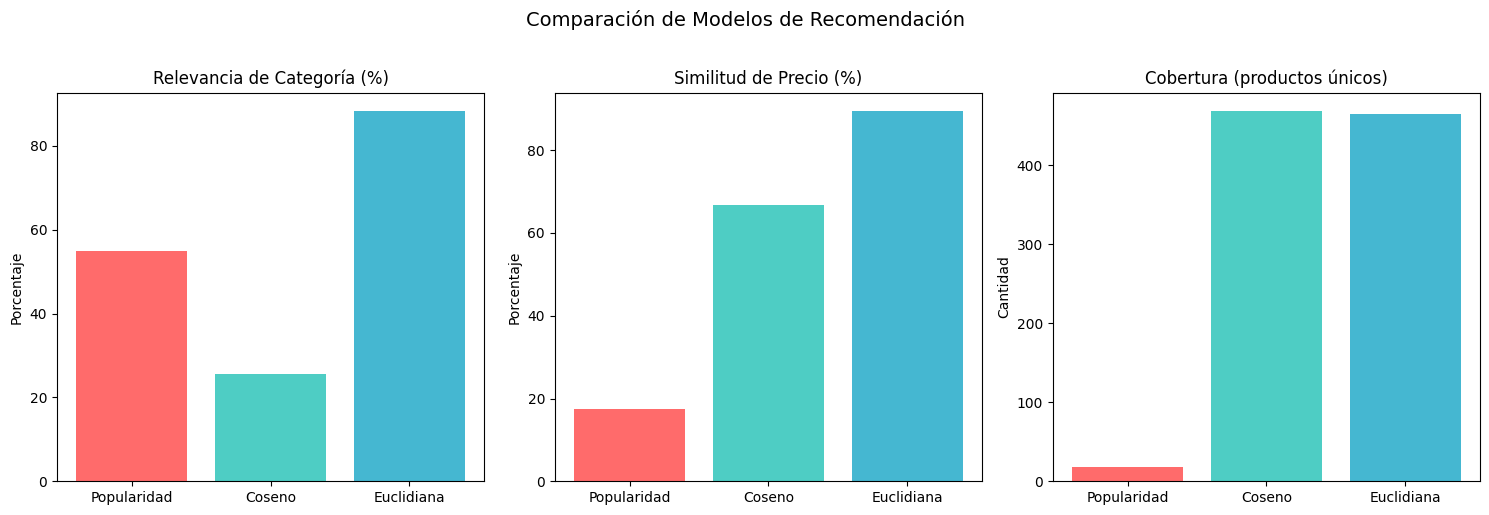

Gráfico guardado como 'comparacion_modelos.png'


In [7]:
"""
VISUALIZACIÓN COMPARATIVA DE MÉTRICAS
"""

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

axes[0].bar(metricas['modelo'], metricas['misma_categoria_%'], color=colors)
axes[0].set_title('Relevancia de Categoría (%)')
axes[0].set_ylabel('Porcentaje')

axes[1].bar(metricas['modelo'], metricas['precio_similar_%'], color=colors)
axes[1].set_title('Similitud de Precio (%)')
axes[1].set_ylabel('Porcentaje')

axes[2].bar(metricas['modelo'], metricas['cobertura'], color=colors)
axes[2].set_title('Cobertura (productos únicos)')
axes[2].set_ylabel('Cantidad')

plt.suptitle('Comparación de Modelos de Recomendación', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico guardado como 'comparacion_modelos.png'")

## 5. Justificación del Modelo Elegido

### Trade-off identificado

Los resultados muestran un trade-off interesante:

| Modelo | Fortaleza | Debilidad |
|--------|-----------|-----------|
| Popularidad | Simple, cobertura muy limitada | No personaliza, precio dispar |
| **Coseno** | **Diversidad de categorías, buen precio** | **Menor relevancia de categoría** |
| Euclidiana | Alta relevancia de categoría y precio | Muy poca diversidad (mismo tipo) |

### Modelo elegido: **Content-Based con Similitud Coseno**

**Razones:**
1. **Objetivo de negocio**: Aumentar el ticket promedio y descubrimiento de productos
2. **Diversidad**: Recomienda productos de distintas categorías con características similares
3. **Robustez a escalas**: Maneja correctamente las diferencias de magnitud entre features
4. **Cobertura amplia**: 468 productos únicos vs 18 del baseline

### Modelos descartados desde el EDA
- **Collaborative Filtering**: 97% clientes únicos sin historial de recompra
- **Market Basket Analysis**: 96.7% órdenes con un solo producto

### Limitaciones reconocidas
- Solo recomienda productos con características similares (no descubre gustos nuevos)
- Depende de la calidad de features del dataset
- Se trabajó con muestra de 5,000 productos por restricciones de memoria en Colab

### Trabajo futuro
- Implementar Collaborative Filtering si aumenta la tasa de recompra
- Incorporar análisis de sentimiento de reviews
- Agregar features de comportamiento de navegación

In [8]:
"""
RESUMEN FINAL Y EJEMPLO DE USO
"""

print("=" * 60)
print("RESUMEN DEL PROYECTO DE MODELADO")
print("=" * 60)
print(f"Dataset limpio:           {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Productos únicos:         {len(product_features):,}")
print(f"Muestra para modelado:    {SAMPLE_SIZE:,} productos")
print(f"Modelos comparados:       3")
print(f"Métricas evaluadas:       3")
print()
print("MODELO ELEGIDO: Content-Based con Similitud Coseno")
print()
print("Métricas finales:")
print(metricas.to_string(index=False))
print()
print("=" * 60)
print("EJEMPLO DE USO EN PRODUCCIÓN")
print("=" * 60)

# Ejemplo interactivo con un producto
producto_ejemplo = product_sample.iloc[0]
print(f"\nCliente compró: {producto_ejemplo['product_category_name']} - ${producto_ejemplo['price']:.2f}")
print(f"Product ID: {producto_ejemplo['product_id'][:20]}...")
print("\nRecomendaciones generadas por el sistema:\n")

recomendaciones = recomendar_coseno(
    producto_ejemplo['product_id'],
    product_sample,
    cosine_sim_matrix,
    top_n=5
)
print(recomendaciones.to_string(index=False))

RESUMEN DEL PROYECTO DE MODELADO
Dataset limpio:           98,771 filas x 16 columnas
Productos únicos:         31,625
Muestra para modelado:    5,000 productos
Modelos comparados:       3
Métricas evaluadas:       3

MODELO ELEGIDO: Content-Based con Similitud Coseno

Métricas finales:
     modelo  misma_categoria_%  precio_similar_%  cobertura
Popularidad               55.0              17.5         18
     Coseno               25.6              66.8        468
 Euclidiana               88.2              89.4        465

EJEMPLO DE USO EN PRODUCCIÓN

Cliente compró: cama_mesa_banho - $108.99
Product ID: 9b76503b35ee45adf532...

Recomendaciones generadas por el sistema:

                      product_id product_category_name  price  similarity_score
dd0fc08054600c8e6c078d6df90ee3fb       cama_mesa_banho 109.90          0.999652
b41bc92e95bff65143623215ead52dba            automotivo  69.90          0.998876
aa2f410b8f9a8e3e6320540174a4edfe       cama_mesa_banho  83.99          0.997879